In [48]:
import sys
from pathlib import Path
import joblib

Duong_Dan_Goc = Path(r"D:\HR Analytics")
sys.path.append(str(Duong_Dan_Goc/"python"/"src"))

import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from db import get_engine

MODEL_DIR = Duong_Dan_Goc / "python" / "models"
OUTPUT_DIR = Duong_Dan_Goc / "python" / "outputs"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)   


In [49]:
engine = get_engine()
query="""
select *
from dw.View_ML_NhanVien
order by NgayThang, MaNV
"""
df = pd.read_sql(query, engine)
df.head()

,MaNV,NgayThang,Nam,PhongBan,ChucDanh,CapBacCongViec,Tuoi,KhoangCachTuNha,SoLuongDuAn,SoGioTrungBinhThang,LamThemGio,DiemDanhGiaHieuSuat,DiemHaiLongCongViec,DiemHaiLongMoiTruong,ThuNhapThang,SoNamTaiCongTy,SoNamTuLanThangChucCuoi,DuocThangChucNamTruoc,TargetNghiViec
0,5,2018-01-01,2018,Information Technology,IT Support,2,41,15,5,194,False,3,2,3,16936000,7,7,False,0
1,6,2018-01-01,2018,Sales,Sales Supervisor,1,29,16,3,206,False,4,4,3,11779000,7,7,False,0
2,7,2018-01-01,2018,Operations,Operations Manager,2,28,36,1,177,False,2,2,3,15588000,4,4,False,1
3,8,2018-01-01,2018,Human Resources,C&B Specialist,3,35,3,4,240,True,3,1,4,33357000,6,6,False,0
4,10,2018-01-01,2018,Human Resources,C&B Specialist,2,38,35,3,166,False,4,2,2,15353000,4,4,False,0


In [50]:
ngay_moi_nhat = df["NgayThang"].max()

df_latest = df[df["NgayThang"] == ngay_moi_nhat].copy()

print(ngay_moi_nhat)

2025-01-01


In [51]:
#Chọn features phù hợp và chuẩn hóa dữ liệu
features_kmeans = [
    "Tuoi",
    "KhoangCachTuNha",
    "SoLuongDuAn",
    "SoGioTrungBinhThang",
    "LamThemGio",
    "DiemDanhGiaHieuSuat",
    "DiemHaiLongCongViec",
    "DiemHaiLongMoiTruong",
    "ThuNhapThang",
    "SoNamTaiCongTy",
    "SoNamTuLanThangChucCuoi",
    "CapBacCongViec"
]

X = df_latest[features_kmeans].copy()

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaled = scaler.fit_transform(X)

In [53]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
#Tìm cụm k bằng thuật toán Elbow và Silhouette

gia_tri_k = range(2, 9)

inertias = []
silhouettes = []

for k in gia_tri_k:
    mo_hinh = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    nhan = mo_hinh.fit_predict(x_scaled)

    inertias.append(mo_hinh.inertia_)
    silhouettes.append(
        silhouette_score(x_scaled, nhan)
    )

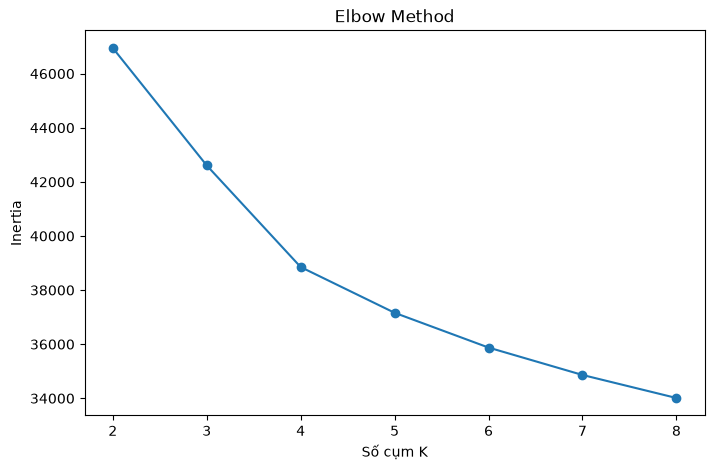

In [54]:
plt.figure(figsize=(8, 5))
plt.plot(list(gia_tri_k), inertias, marker="o")
plt.xlabel("Số cụm K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

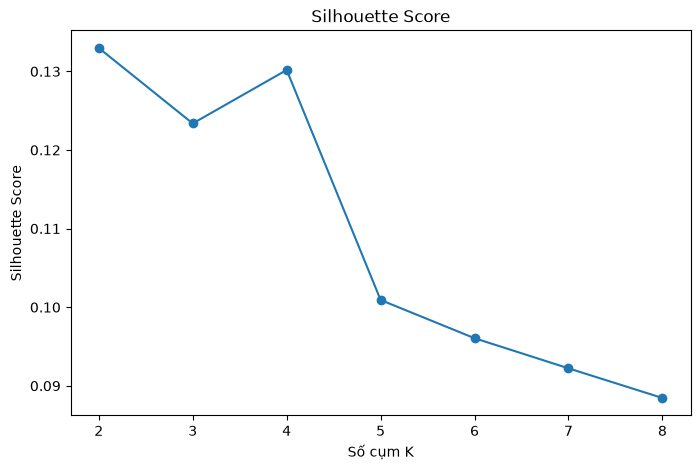

In [55]:
plt.figure(figsize=(8, 5))
plt.plot(list(gia_tri_k), silhouettes, marker="o")
plt.xlabel("Số cụm K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()

In [56]:
ket_qua_k = pd.DataFrame({
    "K": list(gia_tri_k),
    "Inertia": inertias,
    "Silhouette": silhouettes
})

ket_qua_k

,K,Inertia,Silhouette
0,2,46948.169763,0.132978
1,3,42607.209104,0.123377
2,4,38851.864676,0.130178
3,5,37160.497014,0.100916
4,6,35875.456673,0.096050
5,7,34862.553888,0.092222
6,8,34011.442463,0.088446


In [57]:
#Huấn luyện mô hình K-Means với giá trị k là 4
k = 4
k_mean = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=20
)

df_latest["Cluster"] = k_mean.fit_predict(x_scaled)

df_latest[["MaNV", "Cluster"]].head()

,MaNV,Cluster
35210,1,2
35211,3,1
35212,4,1
35213,5,3
35214,10,3


In [58]:
#Kich thuoc cua moi cum
kich_thuoc_cum = (
    df_latest["Cluster"]
    .value_counts()
    .sort_index()
    .rename("SoNhanVien")
)

kich_thuoc_cum

Cluster
0     676
1    1184
2    1813
3     758
Name: SoNhanVien, dtype: int64

In [59]:
phan_bo_cum = pd.DataFrame({
    "SoNhanVien": kich_thuoc_cum
})

phan_bo_cum["TyLePhanTram"] = (
    phan_bo_cum["SoNhanVien"]
    / len(df_latest)
    * 100
).round(2)

phan_bo_cum

,SoNhanVien,TyLePhanTram
Cluster,,
0,676,15.26
1,1184,26.72
2,1813,40.92
3,758,17.11


In [60]:
print("Tong nhan vien:", phan_bo_cum["SoNhanVien"].sum())
print("Tong ty le:", phan_bo_cum["TyLePhanTram"].sum())

Tong nhan vien: 4431
Tong ty le: 100.01


In [61]:
#Dac trung thuc te
dac_trung_cum = (
    df_latest
    .groupby("Cluster")[features_kmeans]
    .mean()
    .round(2)
)

dac_trung_cum

,Tuoi,KhoangCachTuNha,SoLuongDuAn,SoGioTrungBinhThang,LamThemGio,DiemDanhGiaHieuSuat,DiemHaiLongCongViec,DiemHaiLongMoiTruong,ThuNhapThang,SoNamTaiCongTy,SoNamTuLanThangChucCuoi,CapBacCongViec
Cluster,,,,,,,,,,,,
0,44.36,20.12,3.54,196.22,0.27,3.40,2.96,2.74,23196840.24,11.21,9.69,1.80
1,38.13,20.89,3.61,218.09,0.99,3.39,2.96,2.82,19422263.51,4.36,2.63,1.95
2,37.85,20.64,3.42,187.56,0.00,3.39,2.83,2.97,18060525.10,3.42,2.36,1.86
3,39.82,20.15,3.54,196.28,0.29,3.40,2.86,2.80,54903778.36,6.94,3.06,4.08


In [62]:
thong_ke_cum = (
    df_latest
    .groupby("Cluster")
    .agg(
        SoNhanVien=("MaNV", "nunique"),
        SoNghiViec=("TargetNghiViec", "sum"),

        TuoiTB=("Tuoi", "mean"),
        KhoangCachTB=("KhoangCachTuNha", "mean"),
        SoDuAnTB=("SoLuongDuAn", "mean"),
        GioLamTB=("SoGioTrungBinhThang", "mean"),

        TyLeLamThem=("LamThemGio", "mean"),

        HieuSuatTB=("DiemDanhGiaHieuSuat", "mean"),
        HaiLongCongViecTB=("DiemHaiLongCongViec", "mean"),
        HaiLongMoiTruongTB=("DiemHaiLongMoiTruong", "mean"),

        ThuNhapTB=("ThuNhapThang", "mean"),

        ThamNienTB=("SoNamTaiCongTy", "mean"),
        NamTuThangChucTB=(
            "SoNamTuLanThangChucCuoi",
            "mean"
        ),

        TyLeDuocThangChucNamTruoc=(
            "DuocThangChucNamTruoc",
            "mean"
        ),

        CapBacTB=("CapBacCongViec", "mean")
    )
)

thong_ke_cum["TyLeNghiViec"] = (
    thong_ke_cum["SoNghiViec"]
    / thong_ke_cum["SoNhanVien"]
    * 100
)

thong_ke_cum["TyLeLamThem"] *= 100

thong_ke_cum["TyLeDuocThangChucNamTruoc"] *= 100

thong_ke_cum = thong_ke_cum.round(2)

thong_ke_cum

,SoNhanVien,SoNghiViec,TuoiTB,KhoangCachTB,SoDuAnTB,GioLamTB,TyLeLamThem,HieuSuatTB,HaiLongCongViecTB,HaiLongMoiTruongTB,ThuNhapTB,ThamNienTB,NamTuThangChucTB,TyLeDuocThangChucNamTruoc,CapBacTB,TyLeNghiViec
Cluster,,,,,,,,,,,,,,,,
0,676,112,44.36,20.12,3.54,196.22,27.22,3.40,2.96,2.74,23196840.24,11.21,9.69,0.44,1.80,16.57
1,1184,290,38.13,20.89,3.61,218.09,98.99,3.39,2.96,2.82,19422263.51,4.36,2.63,9.54,1.95,24.49
2,1813,169,37.85,20.64,3.42,187.56,0.22,3.39,2.83,2.97,18060525.10,3.42,2.36,8.33,1.86,9.32
3,758,93,39.82,20.15,3.54,196.28,28.63,3.40,2.86,2.80,54903778.36,6.94,3.06,15.44,4.08,12.27


In [63]:
#phan tich phong ban
phong_ban_cum = (df_latest.groupby(["Cluster", "PhongBan"]).size()
    .reset_index(name="SoNhanVien")
)
phong_ban_cum = (phong_ban_cum.sort_values( ["Cluster", "SoNhanVien"], ascending=[True, False]
    )
)
phong_ban_cum.groupby("Cluster").head(3)

,Cluster,PhongBan,SoNhanVien
3,0,Marketing,135
1,0,Human Resources,119
5,0,Sales,115
7,1,Human Resources,208
11,1,Sales,206
9,1,Marketing,204
14,2,Information Technology,344
15,2,Marketing,316
12,2,Finance,309
21,3,Marketing,139


In [64]:
#Phan tich chuc danh
chuc_danh_cum = (df_latest.groupby(["Cluster", "ChucDanh"]).size().reset_index(name="SoNhanVien")
)

chuc_danh_cum = (chuc_danh_cum.sort_values(["Cluster", "SoNhanVien"],ascending=[True, False]))

chuc_danh_cum.groupby("Cluster").head(5)

,Cluster,ChucDanh,SoNhanVien
19,0,Sales Executive,37
5,0,Digital Marketing Specialist,36
13,0,Marketing Manager,36
18,0,Recruiter,35
12,0,Marketing Executive,33
44,1,Sales Executive,70
28,1,Content Specialist,59
27,1,C&B Specialist,55
40,1,Operations Manager,54
43,1,Recruiter,52


In [65]:
#Centroid chuẩn hóa và centroid thực tế
centroid_mac_dinh = pd.DataFrame(
    scaler.inverse_transform(
        k_mean.cluster_centers_
    ),
    columns=features_kmeans
)

centroid_mac_dinh.index.name = "Cluster"

centroid_mac_dinh.round(2)

,Tuoi,KhoangCachTuNha,SoLuongDuAn,SoGioTrungBinhThang,LamThemGio,DiemDanhGiaHieuSuat,DiemHaiLongCongViec,DiemHaiLongMoiTruong,ThuNhapThang,SoNamTaiCongTy,SoNamTuLanThangChucCuoi,CapBacCongViec
Cluster,,,,,,,,,,,,
0,44.36,20.12,3.54,196.22,0.27,3.40,2.96,2.74,23196840.24,11.21,9.69,1.80
1,38.13,20.89,3.61,218.09,0.99,3.39,2.96,2.82,19422263.51,4.36,2.63,1.95
2,37.85,20.64,3.42,187.56,0.00,3.39,2.83,2.97,18060525.10,3.42,2.36,1.86
3,39.82,20.15,3.54,196.28,0.29,3.40,2.86,2.80,54903778.36,6.94,3.06,4.08


In [66]:
centroid_chuan_hoa = pd.DataFrame(
    k_mean.cluster_centers_,
    columns=features_kmeans
)

centroid_chuan_hoa.index.name = "Cluster"

centroid_chuan_hoa.round(2)

,Tuoi,KhoangCachTuNha,SoLuongDuAn,SoGioTrungBinhThang,LamThemGio,DiemDanhGiaHieuSuat,DiemHaiLongCongViec,DiemHaiLongMoiTruong,ThuNhapThang,SoNamTaiCongTy,SoNamTuLanThangChucCuoi,CapBacCongViec
Cluster,,,,,,,,,,,,
0,0.55,-0.04,0.01,-0.09,-0.17,0.01,0.07,-0.12,-0.14,1.42,1.76,-0.41
1,-0.12,0.03,0.06,0.79,1.32,-0.01,0.07,-0.05,-0.36,-0.27,-0.31,-0.27
2,-0.15,0.01,-0.05,-0.44,-0.74,-0.00,-0.06,0.10,-0.44,-0.50,-0.38,-0.35
3,0.06,-0.03,0.02,-0.09,-0.15,0.01,-0.03,-0.06,1.75,0.37,-0.18,1.62


In [67]:
#Đặc trưng nổi bật của từng cụm
for cum in centroid_chuan_hoa.index:

    print(f"\n===== Cụm {cum} =====")

    tam = centroid_chuan_hoa.loc[cum]

    print("\nCao hon trung binh")
    print(
        tam.sort_values(
            ascending=False
        ).head(5).round(2)
    )

    print("\nThap hon trung binh")
    print(
        tam.sort_values(
            ascending=True
        ).head(5).round(2)
    )


===== Cụm 0 =====

Cao hon trung binh
SoNamTuLanThangChucCuoi    1.76
SoNamTaiCongTy             1.42
Tuoi                       0.55
DiemHaiLongCongViec        0.07
SoLuongDuAn                0.01
Name: 0, dtype: float64

Thap hon trung binh
CapBacCongViec         -0.41
LamThemGio             -0.17
ThuNhapThang           -0.14
DiemHaiLongMoiTruong   -0.12
SoGioTrungBinhThang    -0.09
Name: 0, dtype: float64

===== Cụm 1 =====

Cao hon trung binh
LamThemGio             1.32
SoGioTrungBinhThang    0.79
DiemHaiLongCongViec    0.07
SoLuongDuAn            0.06
KhoangCachTuNha        0.03
Name: 1, dtype: float64

Thap hon trung binh
ThuNhapThang              -0.36
SoNamTuLanThangChucCuoi   -0.31
SoNamTaiCongTy            -0.27
CapBacCongViec            -0.27
Tuoi                      -0.12
Name: 1, dtype: float64

===== Cụm 2 =====

Cao hon trung binh
DiemHaiLongMoiTruong    0.10
KhoangCachTuNha         0.01
DiemDanhGiaHieuSuat    -0.00
SoLuongDuAn            -0.05
DiemHaiLongCongViec    -

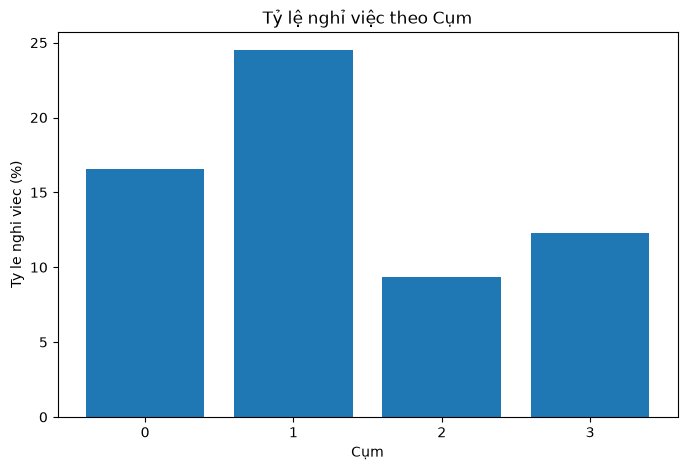

In [68]:
#Biểu đồ tỷ lệ theo việc từng cụm
plt.figure(figsize=(8, 5))

plt.bar(
    thong_ke_cum.index.astype(str),
    thong_ke_cum["TyLeNghiViec"]
)

plt.xlabel("Cụm")
plt.ylabel("Ty le nghi viec (%)")
plt.title("Tỷ lệ nghỉ việc theo Cụm")

plt.show()

In [69]:
ten_cum = {
    0: "Lau nam - thang tien cham",
    1: "Khoi luong cong viec cao - uu tien giu chan",
    2: "It tham nien - Khoi luong cong viec thap",
    3: "Cap bac cao - thu nhap cao"
}

df_latest["TenCum"] = df_latest["Cluster"].map(ten_cum)

df_latest[["MaNV", "Cluster", "TenCum"]].head()

,MaNV,Cluster,TenCum
35210,1,2,It tham nien - Khoi luong cong viec thap
35211,3,1,Khoi luong cong viec cao - uu tien giu chan
35212,4,1,Khoi luong cong viec cao - uu tien giu chan
35213,5,3,Cap bac cao - thu nhap cao
35214,10,3,Cap bac cao - thu nhap cao


In [70]:
bao_cao_cum = thong_ke_cum[
    [
        "SoNhanVien",
        "SoNghiViec",
        "TyLeNghiViec",
        "TuoiTB",
        "ThuNhapTB",
        "GioLamTB",
        "TyLeLamThem",
        "HaiLongCongViecTB",
        "HaiLongMoiTruongTB",
        "ThamNienTB",
        "NamTuThangChucTB"
    ]
].copy()

bao_cao_cum

,SoNhanVien,SoNghiViec,TyLeNghiViec,TuoiTB,ThuNhapTB,GioLamTB,TyLeLamThem,HaiLongCongViecTB,HaiLongMoiTruongTB,ThamNienTB,NamTuThangChucTB
Cluster,,,,,,,,,,,
0,676,112,16.57,44.36,23196840.24,196.22,27.22,2.96,2.74,11.21,9.69
1,1184,290,24.49,38.13,19422263.51,218.09,98.99,2.96,2.82,4.36,2.63
2,1813,169,9.32,37.85,18060525.10,187.56,0.22,2.83,2.97,3.42,2.36
3,758,93,12.27,39.82,54903778.36,196.28,28.63,2.86,2.80,6.94,3.06


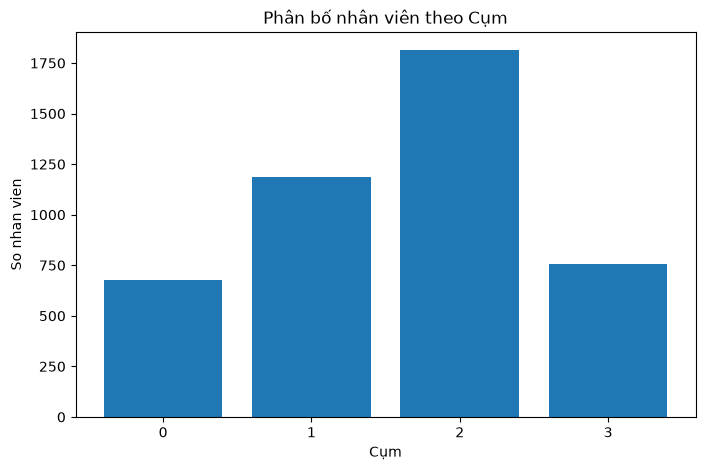

In [71]:
#Biểu đồ phân bố nhân viên theo từng cụm

plt.figure(figsize=(8, 5))

plt.bar(
    phan_bo_cum.index.astype(str),
    phan_bo_cum["SoNhanVien"]
)

plt.xlabel("Cụm")
plt.ylabel("So nhan vien")
plt.title("Phân bố nhân viên theo Cụm")

plt.show()

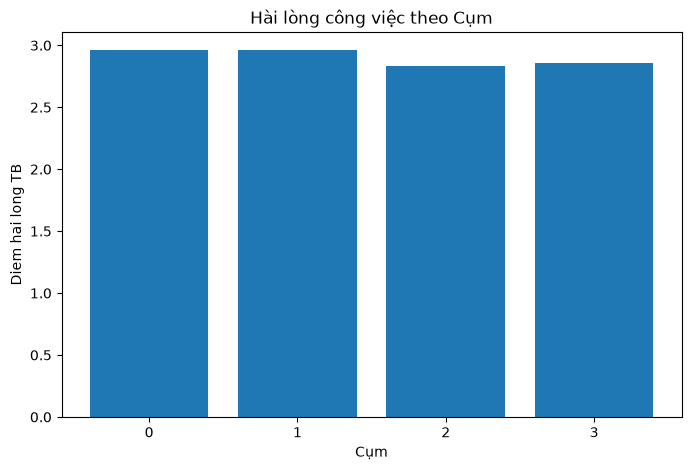

In [72]:
#Biểu đồ điểm hài lòng công việc theo từng cụm
plt.figure(figsize=(8, 5))

plt.bar(
    thong_ke_cum.index.astype(str),
    thong_ke_cum["HaiLongCongViecTB"]
)

plt.xlabel("Cụm")
plt.ylabel("Diem hai long TB")
plt.title("Hài lòng công việc theo Cụm")

plt.show()

In [73]:
#Lưu mô hình Kmeans
joblib.dump(
    scaler,
    MODEL_DIR / "scaler_kmeans.pkl"
)

['D:\\HR Analytics\\python\\models\\scaler_kmeans.pkl']

In [74]:
joblib.dump(
    k_mean,
    MODEL_DIR / "kmeans_model.pkl"
)

['D:\\HR Analytics\\python\\models\\kmeans_model.pkl']

In [76]:
ket_qua_phan_cum = df_latest[
    [
        "MaNV",
        "NgayThang",
        "PhongBan",
        "ChucDanh",
        "Cluster",
        "TenCum",
        "TargetNghiViec"
    ]
].copy()

In [77]:
ket_qua_phan_cum.to_csv(
    OUTPUT_DIR / "ket_qua_phan_cum.csv",
    index=False,
    encoding="utf-8-sig"
)

In [78]:
thong_ke_cum.to_csv(
    OUTPUT_DIR / "tt_cum.csv",
    encoding="utf-8-sig"
)

In [79]:
centroid_mac_dinh.round(2).to_csv(
    OUTPUT_DIR / "Cum_centroid_mac_dinh.csv",
    encoding="utf-8-sig"
)

In [80]:
centroid_chuan_hoa.round(2).to_csv(
    OUTPUT_DIR / "Cum_centroid_chuan_hoa.csv",
    encoding="utf-8-sig"
)